Add Robin boundary conditions.

Success!!!

Author: yanjun zhang

## ds needs define correct

## 1: Start

Source from 
book "Abali - 2017 - Computational Reality" P119

In [1]:
#### import basic
import pyvista
import ufl
import dolfinx
import time
import numpy as np
import matplotlib.pyplot as plt
from petsc4py import PETSc
from mpi4py import MPI
import sys
import os
import shutil

## import speciail library
from dolfinx.fem.petsc import LinearProblem, assemble_vector, assemble_matrix, create_vector, apply_lifting, set_bc
from dolfinx import fem, mesh, io, plot, default_scalar_type, nls, log
from dolfinx.fem import Constant, dirichletbc, Function, FunctionSpace,form,locate_dofs_topological
from dolfinx.io import XDMFFile, gmshio
from dolfinx.mesh import locate_entities,locate_entities_boundary,meshtags
from ufl import SpatialCoordinate, TestFunction, TrialFunction, dx, grad, inner, Measure, dot, FacetNormal
from dolfinx.fem.petsc import NonlinearProblem
from dolfinx.nls.petsc import NewtonSolver

## import own functions
from find_com_e import find_common_e
from rotation_co import rub_rotation


########################################### calculate how long time the simulation it is ################
start_time = time.time()

######################################### mesh-size, contact area coefficient ############################
mesh_min = 10
mesh_max = 30
c_contact = 0.5

########################################## Each time step rotation angular ###############################
degree_rotation = 100
v_angular_initial = 96.62 

############################################### Start time, Final time  ##################################
t = 0
Total_time = 49
t_lag = 4.2

############################################# calculate total num_steps  ##################################
total_angular = v_angular_initial * t_lag +  (v_angular_initial / 2)  * (Total_time - 4)
total_angular = total_angular / np.pi *180       # rad to degree
num_steps = round( total_angular / degree_rotation )

######################################### rubbing element radius, Contact area  ###########################
r_rub = 18.8
S_rub_circle = r_rub**2 * c_contact
S_contact = S_rub_circle * np.pi
S_total = S_contact * 18  #mm2

######################################### initial and brake pad temperature#########################
Ti = 60
Tm = 60

################################## density (kg.m^-3), capacity (J/Kg.K), conductivity (W/m.K)###############
t_u = 1e3 # m to mm
rho = 7850 /(t_u**3)
c = 462
k = 48 / t_u

######################################## mu, P_brake,  r_disc , heat_distribution  ###############
mu = 0.376
P_initial = 274000
r_disc = 0.25
heat_distribution = 0.88

# D_wheel = 920 mm
# v = D_wheel /2 /1000 * v_angular_initial *3.6   # km/h

#dt1 = degree_rotation/180*np.pi / (v_angular_initial)
#num_stops = round (t_lag / dt1)

dt1 = degree_rotation/180*np.pi / ( 96.62 +    (96.62- (96.62/49*4.2) )  ) /2
num_stops = round (t_lag / dt1)
    

P = []
for i in range(num_steps):
    #if i <= num_steps* (t_lag/ Total_time)*2:
    if i <= num_stops:
        P.append(  P_initial/ num_steps  * i  )
    else:
        P.append( P_initial) 

#################################################### time step size ##################################
dt = []
v_angular = [v_angular_initial ]

for i in range(num_steps):
    if i < num_stops:
        dt.append ( degree_rotation/180*np.pi / v_angular[i]  )
        v_angular.append (   96.62- sum(dt)* (96.62/49)  )
    else:
        if v_angular[i] < 0:
           num_steps1 = i
           break
        else:
           dt.append ( degree_rotation/180*np.pi / v_angular[i-1]  )
           v_angular.append ( v_angular[num_stops] -  v_angular[num_stops]/(Total_time - t_lag) * (sum(dt)-t_lag) ) 
   

################################## S_or is the original brake pad rubbing area, 200 cm2. ######################3
S_or = 200
S_new = S_total/100 #mm2 to cm2

############################################# g is the heat source,unit is w/mm2 ###############################
g = []

for i in range(num_steps1):
    g.append ( mu * P[i] * v_angular[i] * r_disc * heat_distribution *2 /(t_u**2)  * (S_or/S_new) )

num_steps = num_steps1

###################################  h is the heat convection coefficient, unit is W/mm2 K  #################
h = 7.75e-5
# radiation is the radiation heat coefficient, unit is W/mm2 K
# stefan-Boltzmann constant theta = 5.67*10e-8 w/m2 k-4,   0.64 is the emmissivity
radiation = 5.670*(10e-8)/(t_u**2)  * 0.64


############################################  print('heat flux g is ',g) #################################
print('1: Time step dt is ',dt[0],'s')
print('2: Convection heat transfer coefficient is',h, ' W/mm2 K')
print('3: Radiation is ',radiation, ' W/mm2 K-4')

total_circle = (v_angular[0] * r_disc * (1/2) * Total_time) / (2*np.pi*r_disc)
total_degree = total_circle * 360
#print('Total circle is ', total_circle,'is equal to ', total_degree )
each_degree = total_degree / num_steps
print('4: Each rotation degree is ', each_degree, ' per time step')
print('5: The first rotation degree is ',v_angular[0] * r_disc * dt[0] *1000 )
print('6: One contact area of rubbing element is ', round(S_contact/100,1), ' cm2')
print('7: Total contact area of 18 rubbing element is', round(S_total/100,1), 'cm2')
print('8: Total numb steps is ', num_steps)

1: Time step dt is  0.018063850672679873 s
2: Convection heat transfer coefficient is 7.75e-05  W/mm2 K
3: Radiation is  3.6287999999999996e-13  W/mm2 K-4
4: Each rotation degree is  113.40300694445932  per time step
5: The first rotation degree is  436.3323129985823
6: One contact area of rubbing element is  5.6  cm2
7: Total contact area of 18 rubbing element is 99.9 cm2
8: Total numb steps is  1196


In [2]:
print(num_steps)
print(len(v_angular))

1196
1197


50.45717004277753


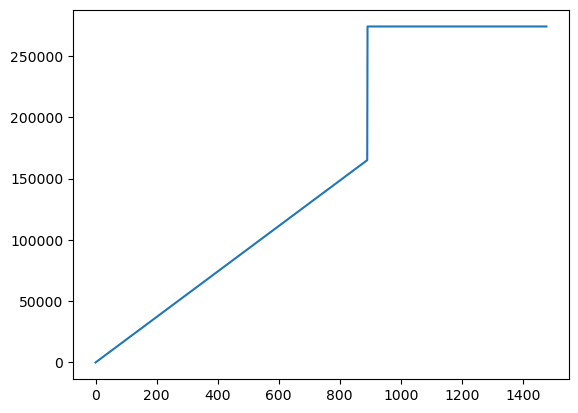

In [3]:
sum_dt = sum(dt)
print(sum_dt)
dt1 = np.linspace(0, 49, num_steps+1)
#plt.plot(dt1 , P)
#plt.plot(v_angular)
#print(dt)
plt.plot(P)
#plt.plot(dt)
#print(v_angular[num_stops] )
#print((sum(dt[:num_stops])-t_lag) )

In [4]:
import dolfinx
print(f"DOLFINx version: {dolfinx.__version__}   \
based on GIT commit:  \
{dolfinx.git_commit_hash} of https://github.com/FEniCS/dolfinx/")

DOLFINx version: 0.8.0   based on GIT commit:  ad7bf8b551a6795a19aaaec058ecba438d55b279 of https://github.com/FEniCS/dolfinx/


## 2: Mesh

In [5]:
######################################  mesh  ###################################3

mesh_name = f"{mesh_min}-{mesh_max}"
mesh_filename1 = "m-{}.msh".format(mesh_name)  
mesh_filename2 = "m-{}".format(mesh_name)  

if os.path.exists(mesh_filename1):
    # Run this command if the file exists
    print(f"The file '{mesh_filename1}' exists, start creat now:")
    domain, cell_markers, facet_markers = gmshio.read_from_msh(mesh_filename1, MPI.COMM_WORLD, 0, gdim=3)

else:
    # Run this command if the file does not exist
    print(f"The file '{mesh_filename1}' does not exist.")
    import sys
    sys.path.append('/home/yanjun/Documents/FEniCSx/Tutorial/Mesh/')
    from mesh_disc import mesh_brake_disc
    mesh_brake_disc(mesh_min, mesh_max,mesh_filename2)
    domain, cell_markers, facet_markers = gmshio.read_from_msh(mesh_filename1, MPI.COMM_WORLD, 0, gdim=3)


# Define variational problem, Here Lagrange changes to CG, what is CG?
V = fem.functionspace(domain, ('CG', 1))

# initialization
def project(function, space):
    u = TrialFunction(space)
    v = TestFunction(space)
    a = inner(u, v) * dx
    L = inner(function, v) * dx
    problem = LinearProblem(a, L, bcs = [])
    return problem.solve()
    
# u_n is for initial condition and uh is the solver result.
# variable, need to be projected form Q onto V
Q = fem.functionspace(domain, ("DG", 0))
T_init = Function(Q)
T_init.name = "u_n"
T_init.x.array[:] = np.full_like(1, Ti, dtype=default_scalar_type)
u_n = project(T_init,V)
u_n.name = "u_n"

fdim = domain.topology.dim - 1
## bc_disc is zero, no any dirichlete boundary condition
bc_disc = mesh.locate_entities_boundary(
    domain, fdim , lambda x:  np.isclose(x[2], 50) )
bc = fem.dirichletbc(PETSc.ScalarType(Tm), fem.locate_dofs_topological(V, fdim, bc_disc), V)
np.set_printoptions(threshold=np.inf)

The file 'm-10-30.msh' exists, start creat now:
Info    : Reading 'm-10-30.msh'...
Info    : 168 entities
Info    : 1548 nodes
Info    : 4825 elements
Info    : Done reading 'm-10-30.msh'


In [6]:
import meshio
mesh1= meshio.read(mesh_filename1)
total_elements = sum( len(cells.data) for cells in mesh1.cells )


## 3: Setup 


In [7]:
xdmf_name = "T-s-{}-d-{}-{}-c-{}-e-{}.xdmf".format(num_steps, degree_rotation, mesh_filename2,c_contact,total_elements)
h5_name = "T-s-{}-d-{}-{}-c-{}-e-{}.h5".format(num_steps, degree_rotation, mesh_filename2,c_contact,total_elements)
xdmf = io.XDMFFile(domain.comm, xdmf_name, "w")
xdmf.write_mesh(domain)

In [8]:
# Create boundary condition
sys.path.append('/home/yanjun/Documents/FEniCSx/Tutorial/Mesh/')
from rub_co import get_rub_coordinate
x_co, y_co = get_rub_coordinate()

boundary1= (10, lambda x: (x[0]-x_co[0])**2 + (x[1]-y_co[0])**2 <= S_rub_circle)
boundary2= (20, lambda x: (x[0]-x_co[1])**2 + (x[1]-y_co[1])**2 <= S_rub_circle) 
boundary3= (30, lambda x: (x[0]-x_co[2])**2 + (x[1]-y_co[2])**2 <= S_rub_circle)
boundary4= (40, lambda x: (x[0]-x_co[3])**2 + (x[1]-y_co[3])**2 <= S_rub_circle) 
boundary5= (50, lambda x: (x[0]-x_co[4])**2 + (x[1]-y_co[4])**2 <= S_rub_circle)
boundary6= (60, lambda x: (x[0]-x_co[5])**2 + (x[1]-y_co[5])**2 <= S_rub_circle) 
boundary7= (70, lambda x: (x[0]-x_co[6])**2 + (x[1]-y_co[6])**2 <= S_rub_circle)
boundary8= (80, lambda x: (x[0]-x_co[7])**2 + (x[1]-y_co[7])**2 <= S_rub_circle) 
boundary9= (90, lambda x: (x[0]-x_co[8])**2 + (x[1]-y_co[8])**2 <= S_rub_circle)
boundary10= (100, lambda x: (x[0]-x_co[9])**2 + (x[1]-y_co[9])**2 <= S_rub_circle) 
boundary11= (110, lambda x: (x[0]-x_co[10])**2 + (x[1]-y_co[10])**2 <= S_rub_circle)
boundary12= (120, lambda x: (x[0]-x_co[11])**2 + (x[1]-y_co[11])**2 <= S_rub_circle) 
boundary13= (130, lambda x: (x[0]-x_co[12])**2 + (x[1]-y_co[12])**2 <= S_rub_circle)
boundary14= (140, lambda x: (x[0]-x_co[13])**2 + (x[1]-y_co[13])**2 <= S_rub_circle) 
boundary15= (150, lambda x: (x[0]-x_co[14])**2 + (x[1]-y_co[14])**2 <= S_rub_circle)
boundary16= (160, lambda x: (x[0]-x_co[15])**2 + (x[1]-y_co[15])**2 <= S_rub_circle)
boundary17= (170, lambda x: (x[0]-x_co[16])**2 + (x[1]-y_co[16])**2 <= S_rub_circle) 
boundary18= (180, lambda x: (x[0]-x_co[17])**2 + (x[1]-y_co[17])**2 <= S_rub_circle)

boundaries1 = [boundary1,boundary2,boundary3,boundary4,boundary5,boundary6,boundary7,boundary8,boundary9,boundary10,
              boundary11,boundary12,boundary13,boundary14,boundary15,boundary16,boundary17,boundary18]
 
facet_indices1, facet_markers1 = [], [] 
fdim = domain.topology.dim - 1  
for (marker, locator) in boundaries1:
        facets = locate_entities(domain, fdim, locator)   
        facet_indices1.append(facets)
        facet_markers1.append(np.full_like(facets, marker))
facet_indices1 = np.hstack(facet_indices1).astype(np.int32)
facet_markers1 = np.hstack(facet_markers1).astype(np.int32)
            
A1 = facet_indices1
B = facet_markers1 
C = mesh.locate_entities_boundary(domain, fdim, lambda x: np.isclose(x[2], 20) )

common_indices1 = np.intersect1d(A1,C)
D = []
for index in common_indices1:
        rows_A1 = np.where(A1 == index)
        D.append( B[rows_A1] )
if len(D) == 0:
       facet_markers1 = []
else:
       facet_markers1 = np.concatenate(D) #concatenate used to join two arrays.

####################################

boundary20 = (200, lambda x:  x[2] == 20)
facet_indices2, facet_markers2 = [], [] 
fdim = domain.topology.dim - 1  
for (marker, locator) in [boundary20]:
        facets = locate_entities(domain, fdim, locator)   
        facet_indices2.append(facets)
        facet_markers2.append(np.full_like(facets, marker)) 
facet_indices2 = np.hstack(facet_indices2).astype(np.int32)
facet_markers2 = np.hstack(facet_markers2).astype(np.int32)

A1 = facet_indices2
B = facet_markers2
B1 = common_indices1
common_indices2 = np.setdiff1d(A1,B1)
D = []
for index in common_indices2:
        rows_A1 = np.where(A1 == index)
        D.append( B[rows_A1] )
if len(D) == 0:
       facet_markers2 = []
else:
       facet_markers2 = np.concatenate(D) #concatenate used to join two arrays.

common_indices3 = [common_indices1,common_indices2]
facet_markers3 = [facet_markers1,facet_markers2]
common_indices3 = np.concatenate(common_indices3).astype(np.int32)
facet_markers3 = np.concatenate(facet_markers3).astype(np.int32)
sorted_indices3 = np.argsort(common_indices3).astype(np.int32)
      
facet_tag = meshtags(domain, fdim, common_indices3[sorted_indices3], facet_markers3[sorted_indices3])
ds = Measure('ds', domain=domain, subdomain_data=facet_tag) 


In [9]:
marker_value = 20
facets_with_marker = facet_tag.indices[facet_tag.values == marker_value]
print(len(facets_with_marker))

0


## 4: Variational equation


In [10]:
a = len( facet_tag.indices[facet_tag.values == 180] )
print( a )


0


In [11]:
uh = fem.Function(V)
uh.name = "uh"
uh = project(T_init,V)
xdmf.write_function(uh, t)

#u = ufl.TrialFunction(V)
u = fem.Function(V)

v = ufl.TestFunction(V)
f = fem.Constant(domain, PETSc.ScalarType(0))
n_vector = FacetNormal(domain)

F = (rho*c)/dt[0]*inner(u,v)*dx + k*inner(grad(u),grad(v))*dx+  h*inner(u,v)*ds(200) + radiation*inner(u**4,v) *ds(200) \
- ( inner(f,v) *dx + (rho*c)/dt[0] * inner(u_n, v) * dx +  h * Tm * v *ds(200) +  radiation * (Tm**4)* v *ds(200) )

#a = (rho*c)/dt*inner(u,v)*dx + k*inner(grad(u),grad(v))*dx+  h*inner(u,v)*ds(200) + radiation*inner(u**4,v) *ds(200)
#L = inner(f,v) *dx + (rho*c)/dt * inner(u_n, v) * dx +  h * 25* v *ds(200) +  radiation * (25**4)* v *ds(200)


for i in list(range(1,19)):
#    i =i+1
#    n_nodes = len( facet_tag.indices[facet_tag.values == 10*(i)] )
#    if n_nodes != 0:
     F +=  - k * dot( grad(u)* v, n_vector) *ds(10*i) - inner(g[0], v) *ds(10*i)
#    else:
#        pass
    
problem = NonlinearProblem(F, u, bcs=[bc])

## 7: Using petsc4py to create a linear solver
solver = NewtonSolver(MPI.COMM_WORLD, problem)
solver.convergence_criterion = "incremental"
solver.rtol = 1e-6
solver.report = True

ksp = solver.krylov_solver
opts = PETSc.Options()
option_prefix = ksp.getOptionsPrefix()
opts[f"{option_prefix}ksp_type"] = "cg"
opts[f"{option_prefix}pc_type"] = "gamg"
opts[f"{option_prefix}pc_factor_mat_solver_type"] = "mumps"
ksp.setFromOptions()

log.set_log_level(log.LogLevel.INFO)
n, converged = solver.solve(u)
assert (converged)
#print(f"Number of interations: {n:d}")


## 8:Visualization of time dependent problem using pyvista
import matplotlib as mpl
pyvista.start_xvfb()
grid = pyvista.UnstructuredGrid(*plot.vtk_mesh(V))
plotter = pyvista.Plotter()

gif_name = "T-s-{}-d-{}-{}-c-{}-e-{}.gif".format(num_steps, degree_rotation, mesh_filename2,c_contact,total_elements)

plotter.open_gif(gif_name, fps=30)
grid.point_data["Temperature"] = u.x.array
warped = grid.warp_by_scalar("Temperature", factor=0)
viridis = mpl.colormaps.get_cmap("viridis").resampled(25)
sargs = dict(title_font_size=25, label_font_size=20,  color="black",
             position_x=0.1, position_y=0.8, width=0.8, height=0.1)
renderer = plotter.add_mesh(warped, show_edges=True, lighting=False,
                            cmap=viridis, scalar_bar_args=sargs,
                            #clim=[0, max(uh.x.array)])
                            clim=[0,  200])

2024-11-02 00:04:06.419 (   1.592s) [main            ]              petsc.cpp:700   INFO| PETSc Krylov solver starting to solve system.
2024-11-02 00:04:06.426 (   1.600s) [main            ]              petsc.cpp:700   INFO| PETSc Krylov solver starting to solve system.
2024-11-02 00:04:06.428 (   1.601s) [main            ]       NewtonSolver.cpp:38    INFO| Newton iteration 2: r (abs) = 0.00607119 (tol = 1e-10) r (rel) = 2.5718e-06(tol = 1e-06)
2024-11-02 00:04:06.430 (   1.604s) [main            ]              petsc.cpp:700   INFO| PETSc Krylov solver starting to solve system.
2024-11-02 00:04:06.432 (   1.605s) [main            ]       NewtonSolver.cpp:38    INFO| Newton iteration 3: r (abs) = 2.98257e-08 (tol = 1e-10) r (rel) = 1.26344e-11(tol = 1e-06)
2024-11-02 00:04:06.432 (   1.605s) [main            ]       NewtonSolver.cpp:252   INFO| Newton solver finished in 3 iterations and 14 linear solver iterations.


## 5: Solution


In [14]:

total_degree = 0
for i in range(num_steps1):
    t += dt[i]
   
    boundaries1 = []
    x_co, y_co = rub_rotation (x_co, y_co, each_degree)   # update the location
    total_degree += degree_rotation  # Incrementing degree by 10 in each step
    
    sys.stdout.write('\r1: Rotation has applied for {} degree. '.format(total_degree))
    sys.stdout.write('2: Current time is ' + str(round(t,1)) + " s. ")
    sys.stdout.write('3: Completion is '  + str(round (100*(t/Total_time),1) )+ " %. ")
    sys.stdout.flush()
    
    boundary1= (10, lambda x: (x[0]-x_co[0])**2 + (x[1]-y_co[0])**2 <= S_rub_circle )
    boundary2= (20, lambda x: (x[0]-x_co[1])**2 + (x[1]-y_co[1])**2 <= S_rub_circle ) 
    boundary3= (30, lambda x: (x[0]-x_co[2])**2 + (x[1]-y_co[2])**2 <= S_rub_circle )
    boundary4= (40, lambda x: (x[0]-x_co[3])**2 + (x[1]-y_co[3])**2 <= S_rub_circle ) 
    boundary5= (50, lambda x: (x[0]-x_co[4])**2 + (x[1]-y_co[4])**2 <= S_rub_circle )
    boundary6= (60, lambda x: (x[0]-x_co[5])**2 + (x[1]-y_co[5])**2 <= S_rub_circle ) 
    boundary7= (70, lambda x: (x[0]-x_co[6])**2 + (x[1]-y_co[6])**2 <= S_rub_circle )
    boundary8= (80, lambda x: (x[0]-x_co[7])**2 + (x[1]-y_co[7])**2 <= S_rub_circle ) 
    boundary9= (90, lambda x: (x[0]-x_co[8])**2 + (x[1]-y_co[8])**2 <= S_rub_circle )
    boundary10= (100, lambda x: (x[0]-x_co[9])**2 + (x[1]-y_co[9])**2 <= S_rub_circle ) 
    boundary11= (110, lambda x: (x[0]-x_co[10])**2 + (x[1]-y_co[10])**2 <= S_rub_circle )
    boundary12= (120, lambda x: (x[0]-x_co[11])**2 + (x[1]-y_co[11])**2 <= S_rub_circle ) 
    boundary13= (130, lambda x: (x[0]-x_co[12])**2 + (x[1]-y_co[12])**2 <= S_rub_circle )
    boundary14= (140, lambda x: (x[0]-x_co[13])**2 + (x[1]-y_co[13])**2 <= S_rub_circle ) 
    boundary15= (150, lambda x: (x[0]-x_co[14])**2 + (x[1]-y_co[14])**2 <= S_rub_circle )
    boundary16= (160, lambda x: (x[0]-x_co[15])**2 + (x[1]-y_co[15])**2 <= S_rub_circle )
    boundary17= (170, lambda x: (x[0]-x_co[16])**2 + (x[1]-y_co[16])**2 <= S_rub_circle ) 
    boundary18= (180, lambda x: (x[0]-x_co[17])**2 + (x[1]-y_co[17])**2 <= S_rub_circle )
   
    boundaries1 = [boundary1,boundary2,boundary3,boundary4,boundary5,boundary6,boundary7,boundary8,boundary9,boundary10,
              boundary11,boundary12,boundary13,boundary14,boundary15,boundary16,boundary17,boundary18]
     
    facet_indices1, facet_markers1 = [], [] 
    fdim = domain.topology.dim - 1  
    for (marker, locator) in boundaries1:
        facets = locate_entities(domain, fdim, locator)   
        facet_indices1.append(facets)
        facet_markers1.append(np.full_like(facets, marker))  
    facet_indices1 = np.hstack(facet_indices1).astype(np.int32)
    facet_markers1 = np.hstack(facet_markers1).astype(np.int32)
    bc_disc = mesh.locate_entities_boundary( domain, fdim , lambda x:  np.isclose(x[2], 20) )        
    A1 = facet_indices1
    B = facet_markers1 
    C = bc_disc
    common_indices1 = np.intersect1d(A1,C)
    D = []
    for index in common_indices1:
        rows_A1 = np.where(A1 == index)
        D.append( B[rows_A1] )
    if len(D) == 0:
       facet_markers1 = []
    else:
       facet_markers1 = np.concatenate(D) #concatenate used to join two arrays.

    ####################################
    
    boundary20 = (200, lambda x:  x[2] == 20)
    facet_indices2, facet_markers2 = [], [] 
    fdim = domain.topology.dim - 1  
    for (marker, locator) in [boundary20]:
        facets = locate_entities(domain, fdim, locator)   
        facet_indices2.append(facets)
        facet_markers2.append(np.full_like(facets, marker)) 
    facet_indices2 = np.hstack(facet_indices2).astype(np.int32)
    facet_markers2 = np.hstack(facet_markers2).astype(np.int32) 
    
    A1 = facet_indices2
    B = facet_markers2
    B1 = common_indices1
    common_indices2 = np.setdiff1d(A1,B1)
    D = []
    for index in common_indices2:
           rows_A1 = np.where(A1 == index)
           D.append( B[rows_A1] )
    if len(D) == 0:
       facet_markers2 = []
    else:
       facet_markers2 = np.concatenate(D) #concatenate used to join two arrays.
    
    
    common_indices3 = [common_indices1,common_indices2]
    facet_markers3 = [facet_markers1,facet_markers2]
    common_indices3 = np.concatenate(common_indices3).astype(np.int32).astype(np.int32)
    facet_markers3 = np.concatenate(facet_markers3).astype(np.int32)

    sorted_indices3 = np.argsort(common_indices3).astype(np.int32)
      
    facet_tag = meshtags(domain, fdim, common_indices3[sorted_indices3], facet_markers3[sorted_indices3])
    ds = Measure('ds', domain=domain, subdomain_data=facet_tag) 

    F = (rho*c)/dt[i]*inner(u,v)*dx + k*inner(grad(u),grad(v))*dx+  h*inner(u,v)*ds(200) + radiation*inner(u**4,v) *ds(200) \
    - ( inner(f,v) *dx + (rho*c)/dt[i] * inner(u_n, v) * dx +  h * 25* v *ds(200) +  radiation * (25**4)* v *ds(200) )

    for j in list(range(1,19)):
         F +=  - k * dot( grad(u)* v, n_vector) *ds(10*j) - inner(g[i], v) *ds(10*j)

    problem = NonlinearProblem(F, u, bcs=[bc])

    ## 7: Using petsc4py to create a linear solver
    solver = NewtonSolver(MPI.COMM_WORLD, problem)
    solver.convergence_criterion = "incremental"
    solver.rtol = 1e-6
    
    ksp = solver.krylov_solver
    opts = PETSc.Options()
    option_prefix = ksp.getOptionsPrefix()
    opts[f"{option_prefix}ksp_type"] = "cg"
    opts[f"{option_prefix}pc_type"] = "gamg"
    opts[f"{option_prefix}pc_factor_mat_solver_type"] = "mumps"
    ksp.setFromOptions()

    sys.stdout.write('\r1: Rotation has applied for {} degree. '.format(total_degree))
    sys.stdout.write('2: Current time is ' + str(round(t,1)) + " s. ")
    sys.stdout.write('3: Completion is '  + str(round (100*(t/Total_time),1) )+ " %. ")
    sys.stdout.flush()

    solver.solve(u)
    u.x.scatter_forward()

    # Update solution at previous time step (u_n)
    u_n.x.array[:] = u.x.array
    # Write solution to file
    xdmf.write_function(u, t)
    # Update plot
    #warped = grid.warp_by_scalar("uh", factor=0)
    plotter.update_coordinates(warped.points.copy(), render=False)
    plotter.update_scalars(u.x.array, render=False)
    plotter.write_frame()
    
plotter.close() 
xdmf.close()
print()

1: Rotation has applied for 100 degree. 2: Current time is 0.1 s. 3: Completion is 0.1 %. 

2024-11-02 00:05:52.154 ( 107.327s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (0,0)
2024-11-02 00:05:52.154 ( 107.327s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (0,0)
2024-11-02 00:05:52.154 ( 107.327s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (0,0)
2024-11-02 00:05:52.154 ( 107.327s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (0,0)
2024-11-02 00:05:52.154 ( 107.327s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (0,0)
2024-11-02 00:05:52.154 ( 107.327s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (0,0)
2024-11-02 00:05:52.154 ( 107.327s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (0,0)
2024-11-02 00:05:52.154 ( 107.328s) [main            ]topologycomputation.cpp:799   INFO| Requesting con

1: Rotation has applied for 200 degree. 2: Current time is 0.1 s. 3: Completion is 0.1 %. 

2024-11-02 00:05:53.125 ( 108.299s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:05:53.125 ( 108.299s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (2,0)
2024-11-02 00:05:53.126 ( 108.299s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:05:53.126 ( 108.299s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (2,0)
2024-11-02 00:05:53.126 ( 108.299s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:05:53.128 ( 108.301s) [main            ]    SparsityPattern.cpp:385   INFO| Column ghost size increased from 0 to 0
2024-11-02 00:05:53.132 ( 108.305s) [main            ]              petsc.cpp:700   INFO| PETSc Krylov solver starting to solve system.
2024-11-02 00:05:53.139 ( 108.312s) [main            ]              petsc.cpp:700   INFO| PETS

1: Rotation has applied for 300 degree. 2: Current time is 0.1 s. 3: Completion is 0.2 %. 

...

1: Rotation has applied for 3600 degree. 2: Current time is 0.7 s. 3: Completion is 1.4 %. 

2024-11-02 00:07:03.355 ( 178.529s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:07:03.355 ( 178.529s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (2,0)
2024-11-02 00:07:03.355 ( 178.529s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:07:03.355 ( 178.529s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (2,0)
2024-11-02 00:07:03.356 ( 178.529s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:07:03.357 ( 178.531s) [main            ]    SparsityPattern.cpp:385   INFO| Column ghost size increased from 0 to 0
2024-11-02 00:07:03.362 ( 178.535s) [main            ]              petsc.cpp:700   INFO| PETSc Krylov solver starting to solve system.
2024-11-02 00:07:03.369 ( 178.542s) [main            ]              petsc.cpp:700   INFO| PETS

1: Rotation has applied for 3700 degree. 2: Current time is 0.7 s. 3: Completion is 1.4 %. 

2024-11-02 00:07:05.452 ( 180.626s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:07:05.452 ( 180.626s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (2,0)
2024-11-02 00:07:05.453 ( 180.626s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:07:05.453 ( 180.626s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (3,0) - (2,0)
2024-11-02 00:07:05.453 ( 180.626s) [main            ]topologycomputation.cpp:799   INFO| Requesting connectivity (2,0) - (3,0)
2024-11-02 00:07:05.455 ( 180.628s) [main            ]    SparsityPattern.cpp:385   INFO| Column ghost size increased from 0 to 0
2024-11-02 00:07:05.459 ( 180.632s) [main            ]              petsc.cpp:700   INFO| PETSc Krylov solver starting to solve system.
2024-11-02 00:07:05.466 ( 180.639s) [main            ]              petsc.cpp:700   INFO| PETS

KeyboardInterrupt: 

In [ ]:
# Display the GIF
from IPython.display import display, Image
display( Image(gif_name) )

In [ ]:
end_time = time.time()
elapsed_time = end_time - start_time
elapsed_time1 = round(elapsed_time, 0)

if elapsed_time1 >= 60:
   min = elapsed_time1/60
   print("Simulation time is",round(min),'min or',elapsed_time1,'second for', num_steps, 'steps')
else:
    print("Simulation time is",elapsed_time1,'second for', num_steps, 'steps')
    

In [ ]:
print('1: First time step dt is ', round(dt[0],5),'s')
print()
print('2: Convection heat transfer coefficient is',h, ' W/mm2 K')
print()
print('3: Radiation is ', round(radiation,14), ' W/mm2 K-4')
print()
print('4: Each rotation degree is ', round(each_degree,1), ' per time step', 'or ', round(each_degree/360,1),' circle')
print()
print('5: The first rotation degree is ', round(v_angular[0] * r_disc * dt[0] *1000, 1) )
print()
print('6: The mid rotation degree is ', round(v_angular[ round(num_steps/2) ] * r_disc * dt[ round(len(dt)/2) ] *1000, 1) )
print()
print('7: The last rotation degree is ', round(v_angular[num_steps1-1] * r_disc * dt[-1] *1000, 1) )
print()
print('8: One contact area of rubbing element is ', round(S_contact/100,1), ' cm2')
print()
print('9: Total contact area of 18 rubbing element is', round(S_total/100,1), 'cm2')
print()
print('10: The mesh element size is between ',mesh_min, '-',mesh_max )
print()
print('11: Total elements number is ',total_elements )

## 6: Simulation time  10 precossors


1: Simulation time is 41 min or 2480.0 second,  T-s-1000-m-3-10-c-1-e-43604.\
2: Simulation time is 9 min or 527.0 second , T-s-1000-m-3-12-c-1-e-25655. \
3:


## 7:Transfer files

In [ ]:

# Define the source directory
source_dir = "/home/yanjun/Documents/FEniCSx/Tutorial/Calculation"

# Define the destination directory
destination_dir = "/home/yanjun/Documents/FEM_results"

# Create the new folder in the destination directory
new_folder_name = f"s-{num_steps}-d-{degree_rotation}-m-{mesh_min}-{mesh_max}-c-{c_contact}-e-{total_elements}"
destination_dir = os.path.join(destination_dir, new_folder_name)
os.makedirs(destination_dir, exist_ok=True)

# List of files to move
files_to_move = [
                 gif_name,
                 h5_name,
                 xdmf_name
                           ]

# Move each file to the destination directory
for filename in files_to_move:
    source_file_path = os.path.join(source_dir, filename)
    destination_file_path = os.path.join(destination_dir, filename)
    shutil.move(source_file_path, destination_file_path)
    print(f"Moved {filename} to {destination_file_path}")